# Semana 10 — Rollout y benchmarking

Esta sesión introduce **rollout** como un procedimiento de mejora de una política base y muestra cómo comparar políticas mediante evaluación exacta y simulación Monte Carlo.

### Objetivos

Al finalizar el laboratorio, el estudiante podrá:

1. construir un MDP con un estado compuesto;
2. evaluar exactamente una política estacionaria;
3. obtener políticas rollout de uno y varios pasos;
4. distinguir un respaldo de Bellman de la evaluación exacta de una política;
5. comparar políticas bajo un mismo criterio descontado;
6. construir intervalos de confianza emparejados para diferencias de desempeño.

### Convenciones de programación

El código central utiliza únicamente:

- arreglos y listas sencillas;
- ciclos `for` y condicionales;
- funciones con parámetros directos;
- matrices de transición organizadas en una lista, una por acción.



---
## 1. Fundamentos: rollout como mejora de políticas

Sea $\pi_0$ una política base y sea $V^{\pi_0}$ su función de valor exacta. El rollout de un paso elige:

$$
\pi_1(s)
=
\arg\max_{a\in\mathcal A(s)}
\left[
r(s,a)
+
\gamma
\sum_{s'}
P(s'|s,a)V^{\pi_0}(s')
\right].
$$

La política $\pi_1$ es greedy respecto de $V^{\pi_0}$. Bajo los supuestos habituales de un MDP descontado:

$$
V^{\pi_1}(s)\geq V^{\pi_0}(s)
\qquad
\text{para todo }s.
$$

### Rollout de varios pasos

Definimos:

$$
V^{(0)}=V^{\pi_0},
$$

y aplicamos respaldos sucesivos de Bellman:

$$
V^{(k)}
=
T V^{(k-1)}.
$$

**Importante:** $V^{(1)}$ es un valor respaldado por Bellman; no es todavía la evaluación exacta de la política rollout-1. El valor exacto de esa política se denota $V^{\pi_1}$ y se obtiene resolviendo su sistema lineal.

Al aumentar la profundidad, los respaldos se aproximan a $V^*$. En un problema particular, rollout-2 puede superar a rollout-1, pero ese orden entre políticas de distintas profundidades debe verificarse empíricamente; la garantía fundamental es la mejora respecto de la política base.

---
## 2. Problema: ColdLink S.A.S.

ColdLink atiende dos puntos de venta, A y B. Al comienzo de cada período decide cuánto reponer en cada uno.

$$
D_A\sim\operatorname{Bin}(4,0.50),
\qquad
D_B\sim\operatorname{Bin}(3,0.60).
$$

El camión puede entregar como máximo cinco unidades por período:

$$
q_A+q_B\leq5.
$$

| Parámetro | Punto A | Punto B |
|:---|---:|---:|
| Precio de venta | 12 | 15 |
| Costo de reposición | 4 | 5 |
| Costo de almacenamiento | 1 | 1 |
| Penalización por faltante | 18 | 22 |
| Capacidad de inventario | 4 | 4 |

Se utiliza $\gamma=0.95$.

### Estado

$$
s=(i_A,i_B),
\qquad
i_A,i_B\in\{0,1,2,3,4\}.
$$

Hay 25 estados.

### Acción

$$
a=(q_A,q_B),
\qquad
q_A+q_B\leq5.
$$

Una acción también debe respetar la capacidad de almacenamiento de cada punto.

### Recompensa

La recompensa conjunta es la suma de las recompensas esperadas de A y B.

### Transición

Como las demandas son independientes:

$$
P((i'_A,i'_B)\mid(i_A,i_B),(q_A,q_B))
=
P_A(i'_A\mid i_A,q_A)
P_B(i'_B\mid i_B,q_B).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

In [2]:
# Parámetros generales
capacidad_inventario = 4
capacidad_camion = 5
gamma = 0.95
penalizacion_infactible = -1000000.0

# Demanda
numero_ensayos_A = 4
probabilidad_exito_A = 0.50

numero_ensayos_B = 3
probabilidad_exito_B = 0.60

# Parámetros económicos
precio_A = 12.0
costo_reposicion_A = 4.0
costo_almacenamiento_A = 1.0
costo_faltante_A = 18.0

precio_B = 15.0
costo_reposicion_B = 5.0
costo_almacenamiento_B = 1.0
costo_faltante_B = 22.0

numero_niveles = capacidad_inventario + 1
numero_estados = numero_niveles * numero_niveles

### Codificación de estados

Para guardar el par $(i_A,i_B)$ en un solo índice utilizamos:

$$
\operatorname{indice}(i_A,i_B)
=
i_A\cdot5+i_B.
$$

Las operaciones `//` y `%` permiten recuperar los dos inventarios.

In [3]:
def codificar_estado(inventario_A, inventario_B):
    indice_estado = (
        inventario_A * numero_niveles
        + inventario_B
    )

    return indice_estado


def decodificar_estado(indice_estado):
    inventario_A = indice_estado // numero_niveles
    inventario_B = indice_estado % numero_niveles

    return inventario_A, inventario_B


indice_ejemplo = codificar_estado(2, 3)
estado_recuperado = decodificar_estado(indice_ejemplo)

print("Índice de (2,3):", indice_ejemplo)
print("Estado recuperado:", estado_recuperado)

Índice de (2,3): 13
Estado recuperado: (2, 3)


### Espacio de acciones

Construimos todas las parejas $(q_A,q_B)$ que respetan la capacidad total del camión.

In [4]:
acciones = []

for cantidad_A in range(numero_niveles):

    for cantidad_B in range(numero_niveles):

        if (
            cantidad_A + cantidad_B
            <= capacidad_camion
        ):
            acciones.append(
                (cantidad_A, cantidad_B)
            )

numero_acciones = len(acciones)

print("Número de estados:", numero_estados)
print("Número de acciones:", numero_acciones)
print("Acciones:", acciones)

Número de estados: 25
Número de acciones: 19
Acciones: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (4, 0), (4, 1)]


### Probabilidades de demanda

Las probabilidades se calculan una sola vez y se reutilizan en todo el cuaderno.

In [5]:
probabilidades_demanda_A = np.zeros(
    numero_ensayos_A + 1
)

for demanda in range(numero_ensayos_A + 1):

    probabilidades_demanda_A[demanda] = (
        binom.pmf(
            demanda,
            numero_ensayos_A,
            probabilidad_exito_A
        )
    )

probabilidades_demanda_B = np.zeros(
    numero_ensayos_B + 1
)

for demanda in range(numero_ensayos_B + 1):

    probabilidades_demanda_B[demanda] = (
        binom.pmf(
            demanda,
            numero_ensayos_B,
            probabilidad_exito_B
        )
    )

print(
    "Probabilidades de A:",
    np.round(probabilidades_demanda_A, 4)
)

print(
    "Probabilidades de B:",
    np.round(probabilidades_demanda_B, 4)
)

Probabilidades de A: [0.0625 0.25   0.375  0.25   0.0625]
Probabilidades de B: [0.064 0.288 0.432 0.216]


---
## 3. Construcción del MDP

Primero construimos cada punto por separado. Para cada inventario y cantidad pedida calculamos:

- la recompensa esperada inmediata;
- la matriz de transición marginal.

Las acciones que exceden la capacidad de inventario reciben una recompensa muy negativa y un autorretorno ficticio.

In [6]:
def construir_modelo_un_punto(
    probabilidades_demanda,
    precio,
    costo_reposicion,
    costo_almacenamiento,
    costo_faltante
):
    numero_demandas = len(probabilidades_demanda)

    retornos = np.zeros(
        (numero_niveles, numero_niveles)
    )

    matrices_transicion = []

    for cantidad_pedida in range(numero_niveles):

        matriz_accion = np.zeros(
            (numero_niveles, numero_niveles)
        )

        for inventario_actual in range(
            numero_niveles
        ):
            inventario_disponible = (
                inventario_actual
                + cantidad_pedida
            )

            if (
                inventario_disponible
                > capacidad_inventario
            ):
                retornos[
                    inventario_actual,
                    cantidad_pedida
                ] = penalizacion_infactible

                matriz_accion[
                    inventario_actual,
                    inventario_actual
                ] = 1.0

            else:
                retorno_esperado = (
                    -costo_reposicion
                    * cantidad_pedida
                )

                for demanda in range(
                    numero_demandas
                ):
                    probabilidad = (
                        probabilidades_demanda[
                            demanda
                        ]
                    )

                    unidades_vendidas = min(
                        inventario_disponible,
                        demanda
                    )

                    inventario_final = max(
                        0,
                        inventario_disponible
                        - demanda
                    )

                    faltante = max(
                        0,
                        demanda
                        - inventario_disponible
                    )

                    retorno_demanda = (
                        precio * unidades_vendidas
                        - costo_almacenamiento
                          * inventario_final
                        - costo_faltante
                          * faltante
                    )

                    retorno_esperado = (
                        retorno_esperado
                        + probabilidad
                          * retorno_demanda
                    )

                    matriz_accion[
                        inventario_actual,
                        inventario_final
                    ] = (
                        matriz_accion[
                            inventario_actual,
                            inventario_final
                        ]
                        + probabilidad
                    )

                retornos[
                    inventario_actual,
                    cantidad_pedida
                ] = retorno_esperado

        matrices_transicion.append(
            matriz_accion
        )

    return retornos, matrices_transicion

In [7]:
retornos_A, transiciones_A = (
    construir_modelo_un_punto(
        probabilidades_demanda_A,
        precio_A,
        costo_reposicion_A,
        costo_almacenamiento_A,
        costo_faltante_A
    )
)

retornos_B, transiciones_B = (
    construir_modelo_un_punto(
        probabilidades_demanda_B,
        precio_B,
        costo_reposicion_B,
        costo_almacenamiento_B,
        costo_faltante_B
    )
)

print(
    "Recompensa A desde i=2, q=1:",
    round(retornos_A[2, 1], 4)
)

print(
    "Recompensa B desde i=2, q=1:",
    round(retornos_B[2, 1], 4)
)

Recompensa A desde i=2, q=1: 17.0625
Recompensa B desde i=2, q=1: 20.8


### Una transición conjunta antes de generalizar

Considere:

- estado actual $(2,2)$;
- acción $(1,1)$;
- estado siguiente $(1,0)$.

Por independencia:

$$
P((1,0)\mid(2,2),(1,1))
=
P_A(1\mid2,1)
P_B(0\mid2,1).
$$

In [8]:
probabilidad_A_ejemplo = (
    transiciones_A[1][2, 1]
)

probabilidad_B_ejemplo = (
    transiciones_B[1][2, 0]
)

probabilidad_conjunta_ejemplo = (
    probabilidad_A_ejemplo
    * probabilidad_B_ejemplo
)

print(
    "Probabilidad marginal de A:",
    round(probabilidad_A_ejemplo, 4)
)

print(
    "Probabilidad marginal de B:",
    round(probabilidad_B_ejemplo, 4)
)

print(
    "Probabilidad conjunta:",
    round(probabilidad_conjunta_ejemplo, 4)
)

Probabilidad marginal de A: 0.375
Probabilidad marginal de B: 0.216
Probabilidad conjunta: 0.081


### MDP conjunto

Las matrices de transición se organizan en una **lista**: una matriz por acción. También construimos una matriz de factibilidad para indicar qué pares estado–acción son válidos.

In [9]:
retornos = np.full(
    (numero_estados, numero_acciones),
    penalizacion_infactible
)

factibilidad = np.zeros(
    (numero_estados, numero_acciones),
    dtype=bool
)

matrices_transicion = []

for indice_accion in range(numero_acciones):

    cantidad_A = acciones[indice_accion][0]
    cantidad_B = acciones[indice_accion][1]

    matriz_accion = np.zeros(
        (numero_estados, numero_estados)
    )

    for inventario_A in range(numero_niveles):

        for inventario_B in range(
            numero_niveles
        ):
            estado_actual = codificar_estado(
                inventario_A,
                inventario_B
            )

            accion_factible = (
                inventario_A + cantidad_A
                <= capacidad_inventario
                and
                inventario_B + cantidad_B
                <= capacidad_inventario
            )

            factibilidad[
                estado_actual,
                indice_accion
            ] = accion_factible

            if accion_factible:
                retornos[
                    estado_actual,
                    indice_accion
                ] = (
                    retornos_A[
                        inventario_A,
                        cantidad_A
                    ]
                    + retornos_B[
                        inventario_B,
                        cantidad_B
                    ]
                )

                for inventario_siguiente_A in range(
                    numero_niveles
                ):

                    for inventario_siguiente_B in range(
                        numero_niveles
                    ):
                        estado_siguiente = (
                            codificar_estado(
                                inventario_siguiente_A,
                                inventario_siguiente_B
                            )
                        )

                        probabilidad_A = (
                            transiciones_A[
                                cantidad_A
                            ][
                                inventario_A,
                                inventario_siguiente_A
                            ]
                        )

                        probabilidad_B = (
                            transiciones_B[
                                cantidad_B
                            ][
                                inventario_B,
                                inventario_siguiente_B
                            ]
                        )

                        matriz_accion[
                            estado_actual,
                            estado_siguiente
                        ] = (
                            probabilidad_A
                            * probabilidad_B
                        )

            else:
                matriz_accion[
                    estado_actual,
                    estado_actual
                ] = 1.0

    matrices_transicion.append(
        matriz_accion
    )

print("MDP conjunto construido.")

MDP conjunto construido.


In [10]:
errores_probabilidad = 0

for indice_accion in range(numero_acciones):

    for estado_actual in range(numero_estados):

        suma_fila = matrices_transicion[
            indice_accion
        ][estado_actual, :].sum()

        if abs(suma_fila - 1.0) > 0.000001:
            errores_probabilidad = (
                errores_probabilidad + 1
            )

if errores_probabilidad == 0:
    print(
        "Todas las filas de transición suman 1."
    )
else:
    print(
        "Filas con problemas:",
        errores_probabilidad
    )

estado_ejemplo = codificar_estado(2, 2)

indice_accion_ejemplo = -1

for indice_accion in range(numero_acciones):

    if acciones[indice_accion] == (1, 1):
        indice_accion_ejemplo = indice_accion

print(
    "Recompensa conjunta en (2,2), acción (1,1):",
    round(
        retornos[
            estado_ejemplo,
            indice_accion_ejemplo
        ],
        4
    )
)

Todas las filas de transición suman 1.
Recompensa conjunta en (2,2), acción (1,1): 37.8625


---
## 4. Iteración de Valor

El siguiente procedimiento usa la misma ecuación estudiada en la semana 8. Primero definimos una función auxiliar que calcula todos los valores estado–acción usando ciclos explícitos.

In [11]:
def calcular_valores_por_accion(
    matrices_transicion,
    retornos,
    factibilidad,
    valor_continuacion,
    gamma
):
    numero_estados_local = retornos.shape[0]
    numero_acciones_local = retornos.shape[1]

    valores_por_accion = np.full(
        (
            numero_estados_local,
            numero_acciones_local
        ),
        penalizacion_infactible
    )

    for estado_actual in range(
        numero_estados_local
    ):

        for accion_actual in range(
            numero_acciones_local
        ):

            if factibilidad[
                estado_actual,
                accion_actual
            ]:
                continuacion = 0.0

                for estado_siguiente in range(
                    numero_estados_local
                ):
                    continuacion = (
                        continuacion
                        + matrices_transicion[
                            accion_actual
                        ][
                            estado_actual,
                            estado_siguiente
                        ]
                        * valor_continuacion[
                            estado_siguiente
                        ]
                    )

                valores_por_accion[
                    estado_actual,
                    accion_actual
                ] = (
                    retornos[
                        estado_actual,
                        accion_actual
                    ]
                    + gamma * continuacion
                )

    return valores_por_accion

In [12]:
tolerancia = 0.000001
maximo_iteraciones = 10000

valor_optimo = np.zeros(numero_estados)
numero_iteraciones = 0

while True:

    numero_iteraciones = numero_iteraciones + 1

    valores_por_accion = (
        calcular_valores_por_accion(
            matrices_transicion,
            retornos,
            factibilidad,
            valor_optimo,
            gamma
        )
    )

    valor_nuevo = np.zeros(numero_estados)

    for estado_actual in range(numero_estados):

        mejor_valor = penalizacion_infactible

        for accion_actual in range(
            numero_acciones
        ):

            if (
                valores_por_accion[
                    estado_actual,
                    accion_actual
                ]
                > mejor_valor
            ):
                mejor_valor = (
                    valores_por_accion[
                        estado_actual,
                        accion_actual
                    ]
                )

        valor_nuevo[estado_actual] = (
            mejor_valor
        )

    cambio_maximo = np.max(
        np.abs(valor_nuevo - valor_optimo)
    )

    valor_optimo = valor_nuevo.copy()

    if cambio_maximo < tolerancia:
        break

    if numero_iteraciones >= maximo_iteraciones:
        break

# Recalcular con el valor final antes de extraer la política
valores_por_accion_finales = (
    calcular_valores_por_accion(
        matrices_transicion,
        retornos,
        factibilidad,
        valor_optimo,
        gamma
    )
)

politica_optima = np.zeros(
    numero_estados,
    dtype=int
)

for estado_actual in range(numero_estados):

    mejor_valor = penalizacion_infactible
    mejor_accion = 0

    for accion_actual in range(
        numero_acciones
    ):

        if (
            valores_por_accion_finales[
                estado_actual,
                accion_actual
            ]
            > mejor_valor
        ):
            mejor_valor = (
                valores_por_accion_finales[
                    estado_actual,
                    accion_actual
                ]
            )

            mejor_accion = accion_actual

    politica_optima[estado_actual] = (
        mejor_accion
    )

print(
    "Actualizaciones de Bellman:",
    numero_iteraciones
)

print(
    "V*(0,0):",
    round(
        valor_optimo[
            codificar_estado(0, 0)
        ],
        2
    )
)

print(
    "Acción óptima en (0,0):",
    acciones[
        politica_optima[
            codificar_estado(0, 0)
        ]
    ]
)

Actualizaciones de Bellman: 337
V*(0,0): 590.14
Acción óptima en (0,0): (3, 2)


### Política óptima en forma de tabla

Cada celda muestra la pareja $(q_A,q_B)$ elegida para el estado correspondiente.

In [13]:
for inventario_A in range(numero_niveles):

    fila_acciones = []

    for inventario_B in range(numero_niveles):

        estado_actual = codificar_estado(
            inventario_A,
            inventario_B
        )

        accion_elegida = acciones[
            politica_optima[estado_actual]
        ]

        fila_acciones.append(
            accion_elegida
        )

    print(
        "i_A =",
        inventario_A,
        ":",
        fila_acciones
    )

i_A = 0 : [(3, 2), (3, 2), (4, 1), (4, 0), (4, 0)]
i_A = 1 : [(2, 3), (3, 2), (3, 1), (3, 0), (3, 0)]
i_A = 2 : [(2, 3), (2, 2), (2, 1), (2, 0), (2, 0)]
i_A = 3 : [(1, 3), (1, 2), (1, 1), (1, 0), (1, 0)]
i_A = 4 : [(0, 3), (0, 2), (0, 1), (0, 0), (0, 0)]


### 🎨 Visualización proporcionada

Las dos celdas siguientes solo apoyan la interpretación de la política. No es necesario dominar la sintaxis de Matplotlib.

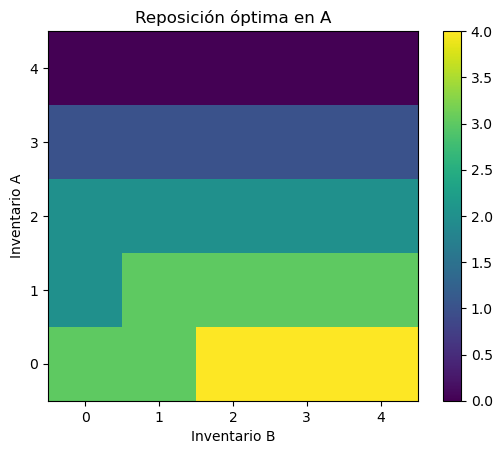

In [14]:
mapa_A = np.zeros(
    (numero_niveles, numero_niveles)
)

for inventario_A in range(numero_niveles):

    for inventario_B in range(numero_niveles):

        estado_actual = codificar_estado(
            inventario_A,
            inventario_B
        )

        accion_elegida = acciones[
            politica_optima[estado_actual]
        ]

        mapa_A[
            inventario_A,
            inventario_B
        ] = accion_elegida[0]

plt.imshow(
    mapa_A,
    origin="lower"
)

plt.xlabel("Inventario B")
plt.ylabel("Inventario A")
plt.title("Reposición óptima en A")
plt.colorbar()
plt.show()

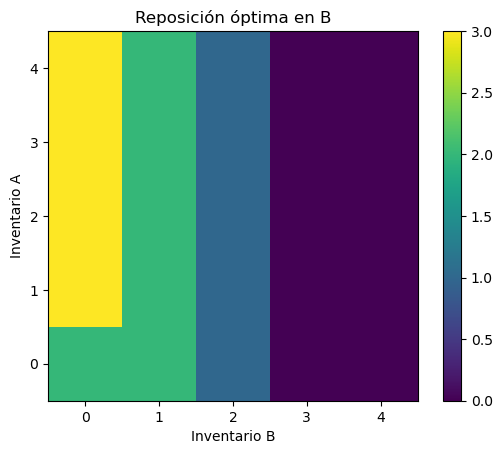

In [15]:
mapa_B = np.zeros(
    (numero_niveles, numero_niveles)
)

for inventario_A in range(numero_niveles):

    for inventario_B in range(numero_niveles):

        estado_actual = codificar_estado(
            inventario_A,
            inventario_B
        )

        accion_elegida = acciones[
            politica_optima[estado_actual]
        ]

        mapa_B[
            inventario_A,
            inventario_B
        ] = accion_elegida[1]

plt.imshow(
    mapa_B,
    origin="lower"
)

plt.xlabel("Inventario B")
plt.ylabel("Inventario A")
plt.title("Reposición óptima en B")
plt.colorbar()
plt.show()

---
## 5. Política base $(s,S)^2$

Usamos:

- A: $(s_A,S_A)=(1,3)$;
- B: $(s_B,S_B)=(1,3)$.

Si la suma pedida supera la capacidad del camión, se prioriza el punto con mayor razón $b_X/p_X$.

In [16]:
punto_reorden_A = 1
nivel_objetivo_A = 3

punto_reorden_B = 1
nivel_objetivo_B = 3

# Caso (1,2)
inventario_A = 1
inventario_B = 2

if inventario_A <= punto_reorden_A:
    cantidad_A = (
        nivel_objetivo_A - inventario_A
    )
else:
    cantidad_A = 0

if inventario_B <= punto_reorden_B:
    cantidad_B = (
        nivel_objetivo_B - inventario_B
    )
else:
    cantidad_B = 0

print(
    "Acción manual en (1,2):",
    (cantidad_A, cantidad_B)
)

# Caso (0,0)
inventario_A = 0
inventario_B = 0

cantidad_A_conflicto = (
    nivel_objetivo_A - inventario_A
)

cantidad_B_conflicto = (
    nivel_objetivo_B - inventario_B
)

if (
    cantidad_A_conflicto
    + cantidad_B_conflicto
    > capacidad_camion
):
    riesgo_A = (
        costo_faltante_A / precio_A
    )

    riesgo_B = (
        costo_faltante_B / precio_B
    )

    if riesgo_A >= riesgo_B:
        cantidad_A_conflicto = min(
            cantidad_A_conflicto,
            capacidad_camion
        )

        cantidad_B_conflicto = min(
            cantidad_B_conflicto,
            capacidad_camion
            - cantidad_A_conflicto
        )

    else:
        cantidad_B_conflicto = min(
            cantidad_B_conflicto,
            capacidad_camion
        )

        cantidad_A_conflicto = min(
            cantidad_A_conflicto,
            capacidad_camion
            - cantidad_B_conflicto
        )

print(
    "Acción manual en (0,0):",
    (
        cantidad_A_conflicto,
        cantidad_B_conflicto
    )
)

Acción manual en (1,2): (2, 0)
Acción manual en (0,0): (3, 2)


In [17]:
def buscar_indice_accion(
    acciones,
    accion_buscada
):
    indice_encontrado = -1

    for indice_accion in range(len(acciones)):

        if acciones[indice_accion] == accion_buscada:
            indice_encontrado = indice_accion
            break

    return indice_encontrado


def construir_politica_base():
    politica = np.zeros(
        numero_estados,
        dtype=int
    )

    for estado_actual in range(numero_estados):

        inventario_A, inventario_B = (
            decodificar_estado(
                estado_actual
            )
        )

        if inventario_A <= punto_reorden_A:
            cantidad_A = (
                nivel_objetivo_A
                - inventario_A
            )
        else:
            cantidad_A = 0

        if inventario_B <= punto_reorden_B:
            cantidad_B = (
                nivel_objetivo_B
                - inventario_B
            )
        else:
            cantidad_B = 0

        cantidad_A = min(
            cantidad_A,
            capacidad_inventario
            - inventario_A
        )

        cantidad_B = min(
            cantidad_B,
            capacidad_inventario
            - inventario_B
        )

        if (
            cantidad_A + cantidad_B
            > capacidad_camion
        ):
            riesgo_A = (
                costo_faltante_A / precio_A
            )

            riesgo_B = (
                costo_faltante_B / precio_B
            )

            if riesgo_A >= riesgo_B:
                cantidad_A = min(
                    cantidad_A,
                    capacidad_camion
                )

                cantidad_B = min(
                    cantidad_B,
                    capacidad_camion
                    - cantidad_A
                )

            else:
                cantidad_B = min(
                    cantidad_B,
                    capacidad_camion
                )

                cantidad_A = min(
                    cantidad_A,
                    capacidad_camion
                    - cantidad_B
                )

        indice_accion = buscar_indice_accion(
            acciones,
            (cantidad_A, cantidad_B)
        )

        politica[estado_actual] = (
            indice_accion
        )

    return politica


politica_base = construir_politica_base()

print(
    "Acción de la función en (1,2):",
    acciones[
        politica_base[
            codificar_estado(1, 2)
        ]
    ]
)

print(
    "Acción de la función en (0,0):",
    acciones[
        politica_base[
            codificar_estado(0, 0)
        ]
    ]
)

Acción de la función en (1,2): (2, 0)
Acción de la función en (0,0): (3, 2)


### Evaluación exacta de una política

Para una política estacionaria $\pi$:

$$
(I-\gamma P^\pi)V^\pi=r^\pi.
$$

In [18]:
def evaluar_politica_exacta(
    politica,
    matrices_transicion,
    retornos,
    gamma
):
    numero_estados_local = retornos.shape[0]

    matriz_politica = np.zeros(
        (
            numero_estados_local,
            numero_estados_local
        )
    )

    retorno_politica = np.zeros(
        numero_estados_local
    )

    for estado_actual in range(
        numero_estados_local
    ):
        accion_elegida = politica[
            estado_actual
        ]

        matriz_politica[
            estado_actual, :
        ] = matrices_transicion[
            accion_elegida
        ][estado_actual, :]

        retorno_politica[
            estado_actual
        ] = retornos[
            estado_actual,
            accion_elegida
        ]

    identidad = np.eye(
        numero_estados_local
    )

    valor_politica = np.linalg.solve(
        identidad - gamma * matriz_politica,
        retorno_politica
    )

    return valor_politica


valor_base = evaluar_politica_exacta(
    politica_base,
    matrices_transicion,
    retornos,
    gamma
)

print(
    "V_base(0,0):",
    round(
        valor_base[
            codificar_estado(0, 0)
        ],
        2
    )
)

print(
    "V*(0,0):",
    round(
        valor_optimo[
            codificar_estado(0, 0)
        ],
        2
    )
)

V_base(0,0): 517.79
V*(0,0): 590.14


---
## 6. Rollout de un paso

Calculamos:

$$
Q^{(1)}(s,a)
=
r(s,a)
+
\gamma
\sum_{s'}
P(s'|s,a)V^{\pi_0}(s').
$$

Después elegimos la acción con mayor valor en cada estado.

In [19]:
valores_rollout_1 = (
    calcular_valores_por_accion(
        matrices_transicion,
        retornos,
        factibilidad,
        valor_base,
        gamma
    )
)

politica_rollout_1 = np.zeros(
    numero_estados,
    dtype=int
)

valor_respaldo_1 = np.zeros(
    numero_estados
)

for estado_actual in range(numero_estados):

    mejor_valor = penalizacion_infactible
    mejor_accion = 0

    for accion_actual in range(
        numero_acciones
    ):

        if (
            valores_rollout_1[
                estado_actual,
                accion_actual
            ]
            > mejor_valor
        ):
            mejor_valor = (
                valores_rollout_1[
                    estado_actual,
                    accion_actual
                ]
            )

            mejor_accion = accion_actual

    politica_rollout_1[
        estado_actual
    ] = mejor_accion

    valor_respaldo_1[
        estado_actual
    ] = mejor_valor

print(
    "Acción rollout-1 en (0,0):",
    acciones[
        politica_rollout_1[
            codificar_estado(0, 0)
        ]
    ]
)

Acción rollout-1 en (0,0): (3, 2)


## 7. Rollout de dos pasos

El vector `valor_respaldo_1` es $T V^{\pi_0}$. No es la evaluación exacta de rollout-1. Lo utilizamos como continuación para realizar un segundo respaldo.

In [20]:
valores_rollout_2 = (
    calcular_valores_por_accion(
        matrices_transicion,
        retornos,
        factibilidad,
        valor_respaldo_1,
        gamma
    )
)

politica_rollout_2 = np.zeros(
    numero_estados,
    dtype=int
)

for estado_actual in range(numero_estados):

    mejor_valor = penalizacion_infactible
    mejor_accion = 0

    for accion_actual in range(
        numero_acciones
    ):

        if (
            valores_rollout_2[
                estado_actual,
                accion_actual
            ]
            > mejor_valor
        ):
            mejor_valor = (
                valores_rollout_2[
                    estado_actual,
                    accion_actual
                ]
            )

            mejor_accion = accion_actual

    politica_rollout_2[
        estado_actual
    ] = mejor_accion

print(
    "Acción rollout-2 en (0,0):",
    acciones[
        politica_rollout_2[
            codificar_estado(0, 0)
        ]
    ]
)

Acción rollout-2 en (0,0): (3, 2)


### Función reutilizable

Ya observamos el patrón para uno y dos pasos. Ahora lo empaquetamos en una función que recibe una matriz de factibilidad, no otra función.

In [21]:
def calcular_rollout_k_pasos(
    matrices_transicion,
    retornos,
    factibilidad,
    valor_base,
    gamma,
    numero_pasos
):
    numero_estados_local = retornos.shape[0]
    numero_acciones_local = retornos.shape[1]

    valor_continuacion = valor_base.copy()

    for paso in range(1, numero_pasos):

        valores_por_accion = (
            calcular_valores_por_accion(
                matrices_transicion,
                retornos,
                factibilidad,
                valor_continuacion,
                gamma
            )
        )

        valor_nuevo = np.full(
            numero_estados_local,
            penalizacion_infactible
        )

        for estado_actual in range(
            numero_estados_local
        ):

            mejor_valor = (
                penalizacion_infactible
            )

            for accion_actual in range(
                numero_acciones_local
            ):

                if (
                    valores_por_accion[
                        estado_actual,
                        accion_actual
                    ]
                    > mejor_valor
                ):
                    mejor_valor = (
                        valores_por_accion[
                            estado_actual,
                            accion_actual
                        ]
                    )

            valor_nuevo[estado_actual] = (
                mejor_valor
            )

        valor_continuacion = (
            valor_nuevo.copy()
        )

    valores_finales = (
        calcular_valores_por_accion(
            matrices_transicion,
            retornos,
            factibilidad,
            valor_continuacion,
            gamma
        )
    )

    politica = np.zeros(
        numero_estados_local,
        dtype=int
    )

    for estado_actual in range(
        numero_estados_local
    ):

        mejor_valor = (
            penalizacion_infactible
        )

        mejor_accion = 0

        for accion_actual in range(
            numero_acciones_local
        ):

            if (
                valores_finales[
                    estado_actual,
                    accion_actual
                ]
                > mejor_valor
            ):
                mejor_valor = (
                    valores_finales[
                        estado_actual,
                        accion_actual
                    ]
                )

                mejor_accion = accion_actual

        politica[estado_actual] = (
            mejor_accion
        )

    return politica

In [22]:
politica_rollout_1_funcion = (
    calcular_rollout_k_pasos(
        matrices_transicion,
        retornos,
        factibilidad,
        valor_base,
        gamma,
        1
    )
)

politica_rollout_2_funcion = (
    calcular_rollout_k_pasos(
        matrices_transicion,
        retornos,
        factibilidad,
        valor_base,
        gamma,
        2
    )
)

print(
    "Rollout-1 coincide:",
    np.array_equal(
        politica_rollout_1,
        politica_rollout_1_funcion
    )
)

print(
    "Rollout-2 coincide:",
    np.array_equal(
        politica_rollout_2,
        politica_rollout_2_funcion
    )
)

Rollout-1 coincide: True
Rollout-2 coincide: True


### Evaluación exacta y mejora

La comparación rollout-1 versus política base corresponde a la garantía teórica. La comparación rollout-2 versus rollout-1 se reporta como un resultado observado en ColdLink.

In [23]:
valor_rollout_1 = evaluar_politica_exacta(
    politica_rollout_1,
    matrices_transicion,
    retornos,
    gamma
)

valor_rollout_2 = evaluar_politica_exacta(
    politica_rollout_2,
    matrices_transicion,
    retornos,
    gamma
)

# La política obtenida con VI se evalúa exactamente
# antes de compararla con las demás.
valor_optimo_exacto = evaluar_politica_exacta(
    politica_optima,
    matrices_transicion,
    retornos,
    gamma
)

mejora_rollout_1 = True
mejora_rollout_2_observada = True
optimo_supera_rollout_2 = True

for estado_actual in range(numero_estados):

    if (
        valor_rollout_1[estado_actual]
        < valor_base[estado_actual] - 0.000001
    ):
        mejora_rollout_1 = False

    if (
        valor_rollout_2[estado_actual]
        < valor_rollout_1[estado_actual]
        - 0.000001
    ):
        mejora_rollout_2_observada = False

    if (
        valor_optimo_exacto[estado_actual]
        < valor_rollout_2[estado_actual]
        - 0.000001
    ):
        optimo_supera_rollout_2 = False

print(
    "Garantía observada V_rollout1 >= V_base:",
    mejora_rollout_1
)

print(
    "Resultado del caso V_rollout2 >= V_rollout1:",
    mejora_rollout_2_observada
)

print(
    "Valor exacto de VI >= V_rollout2:",
    optimo_supera_rollout_2
)

estados_diferentes = 0

for estado_actual in range(numero_estados):

    if (
        politica_rollout_2[estado_actual]
        != politica_optima[estado_actual]
    ):
        estados_diferentes = (
            estados_diferentes + 1
        )

print(
    "Estados donde rollout-2 difiere de VI:",
    estados_diferentes
)

Garantía observada V_rollout1 >= V_base: True
Resultado del caso V_rollout2 >= V_rollout1: True
Valor exacto de VI >= V_rollout2: True
Estados donde rollout-2 difiere de VI: 0


---
## 8. Benchmarking mediante escenarios comunes

Todas las políticas fueron diseñadas con retorno descontado. Por coherencia, la simulación evalúa:

$$
\sum_{t=0}^{T-1}\gamma^t r_t.
$$

Primero generamos una sola colección de demandas y la reutilizamos para todas las políticas. De esta manera, las diferencias entre políticas pueden analizarse con intervalos de confianza **emparejados**.

In [24]:
numero_simulaciones = 2000
numero_periodos = 100
semilla = 42

generador = np.random.default_rng(
    semilla
)

escenarios_demanda_A = (
    generador.binomial(
        numero_ensayos_A,
        probabilidad_exito_A,
        size=(
            numero_simulaciones,
            numero_periodos
        )
    )
)

escenarios_demanda_B = (
    generador.binomial(
        numero_ensayos_B,
        probabilidad_exito_B,
        size=(
            numero_simulaciones,
            numero_periodos
        )
    )
)

print(
    "Escenarios generados:",
    escenarios_demanda_A.shape
)

Escenarios generados: (2000, 100)


### Un episodio explícito

Antes de crear la función, simulamos diez períodos bajo la política base usando el primer escenario.

In [25]:
estado_actual = codificar_estado(0, 0)
retorno_acumulado = 0.0
periodos_demostracion = 10

for periodo in range(periodos_demostracion):

    indice_accion = politica_base[
        estado_actual
    ]

    cantidad_A = acciones[
        indice_accion
    ][0]

    cantidad_B = acciones[
        indice_accion
    ][1]

    inventario_A, inventario_B = (
        decodificar_estado(
            estado_actual
        )
    )

    inventario_disponible_A = (
        inventario_A + cantidad_A
    )

    inventario_disponible_B = (
        inventario_B + cantidad_B
    )

    demanda_A = escenarios_demanda_A[
        0,
        periodo
    ]

    demanda_B = escenarios_demanda_B[
        0,
        periodo
    ]

    ingreso = (
        precio_A
        * min(
            inventario_disponible_A,
            demanda_A
        )
        + precio_B
        * min(
            inventario_disponible_B,
            demanda_B
        )
    )

    costo_reposicion = (
        costo_reposicion_A * cantidad_A
        + costo_reposicion_B * cantidad_B
    )

    inventario_final_A = max(
        0,
        inventario_disponible_A
        - demanda_A
    )

    inventario_final_B = max(
        0,
        inventario_disponible_B
        - demanda_B
    )

    faltante_A = max(
        0,
        demanda_A
        - inventario_disponible_A
    )

    faltante_B = max(
        0,
        demanda_B
        - inventario_disponible_B
    )

    retorno_periodo = (
        ingreso
        - costo_reposicion
        - costo_almacenamiento_A
          * inventario_final_A
        - costo_almacenamiento_B
          * inventario_final_B
        - costo_faltante_A
          * faltante_A
        - costo_faltante_B
          * faltante_B
    )

    retorno_acumulado = (
        retorno_acumulado
        + gamma**periodo
          * retorno_periodo
    )

    estado_actual = codificar_estado(
        inventario_final_A,
        inventario_final_B
    )

    print(
        "Período",
        periodo,
        "- acción:",
        (cantidad_A, cantidad_B),
        "- demanda:",
        (demanda_A, demanda_B),
        "- retorno:",
        round(retorno_periodo, 2)
    )

print(
    "Retorno descontado acumulado:",
    round(retorno_acumulado, 2)
)

Período 0 - acción: (3, 2) - demanda: (3, 2) - retorno: 44.0
Período 1 - acción: (3, 2) - demanda: (2, 2) - retorno: 31.0
Período 2 - acción: (2, 3) - demanda: (3, 1) - retorno: 26.0
Período 3 - acción: (3, 0) - demanda: (3, 2) - retorno: 54.0
Período 4 - acción: (3, 2) - demanda: (1, 1) - retorno: 2.0
Período 5 - acción: (0, 2) - demanda: (4, 2) - retorno: 7.0
Período 6 - acción: (3, 2) - demanda: (3, 2) - retorno: 43.0
Período 7 - acción: (3, 2) - demanda: (3, 1) - retorno: 27.0
Período 8 - acción: (3, 0) - demanda: (1, 2) - retorno: 28.0
Período 9 - acción: (0, 3) - demanda: (2, 2) - retorno: 38.0
Retorno descontado acumulado: 243.25


In [26]:
def simular_politica(
    politica,
    escenarios_demanda_A,
    escenarios_demanda_B,
    estado_inicial,
    gamma
):
    numero_simulaciones_local = (
        escenarios_demanda_A.shape[0]
    )

    numero_periodos_local = (
        escenarios_demanda_A.shape[1]
    )

    retornos_simulados = np.zeros(
        numero_simulaciones_local
    )

    for simulacion in range(
        numero_simulaciones_local
    ):
        estado_actual = estado_inicial
        retorno_acumulado = 0.0

        for periodo in range(
            numero_periodos_local
        ):
            indice_accion = politica[
                estado_actual
            ]

            cantidad_A = acciones[
                indice_accion
            ][0]

            cantidad_B = acciones[
                indice_accion
            ][1]

            inventario_A, inventario_B = (
                decodificar_estado(
                    estado_actual
                )
            )

            inventario_disponible_A = (
                inventario_A
                + cantidad_A
            )

            inventario_disponible_B = (
                inventario_B
                + cantidad_B
            )

            demanda_A = (
                escenarios_demanda_A[
                    simulacion,
                    periodo
                ]
            )

            demanda_B = (
                escenarios_demanda_B[
                    simulacion,
                    periodo
                ]
            )

            ingreso = (
                precio_A
                * min(
                    inventario_disponible_A,
                    demanda_A
                )
                + precio_B
                * min(
                    inventario_disponible_B,
                    demanda_B
                )
            )

            costo_reposicion = (
                costo_reposicion_A
                * cantidad_A
                + costo_reposicion_B
                * cantidad_B
            )

            inventario_final_A = max(
                0,
                inventario_disponible_A
                - demanda_A
            )

            inventario_final_B = max(
                0,
                inventario_disponible_B
                - demanda_B
            )

            faltante_A = max(
                0,
                demanda_A
                - inventario_disponible_A
            )

            faltante_B = max(
                0,
                demanda_B
                - inventario_disponible_B
            )

            retorno_periodo = (
                ingreso
                - costo_reposicion
                - costo_almacenamiento_A
                  * inventario_final_A
                - costo_almacenamiento_B
                  * inventario_final_B
                - costo_faltante_A
                  * faltante_A
                - costo_faltante_B
                  * faltante_B
            )

            retorno_acumulado = (
                retorno_acumulado
                + gamma**periodo
                  * retorno_periodo
            )

            estado_actual = codificar_estado(
                inventario_final_A,
                inventario_final_B
            )

        retornos_simulados[
            simulacion
        ] = retorno_acumulado

    return retornos_simulados

In [27]:
politicas = [
    politica_optima,
    politica_base,
    politica_rollout_1,
    politica_rollout_2
]

nombres_politicas = [
    "VI",
    "Heurística",
    "Rollout-1",
    "Rollout-2"
]

numero_politicas = len(politicas)

resultados_simulacion = np.zeros(
    (
        numero_politicas,
        numero_simulaciones
    )
)

medias = np.zeros(numero_politicas)
errores_estandar = np.zeros(
    numero_politicas
)

estado_inicial = codificar_estado(0, 0)

for indice_politica in range(
    numero_politicas
):

    resultados = simular_politica(
        politicas[indice_politica],
        escenarios_demanda_A,
        escenarios_demanda_B,
        estado_inicial,
        gamma
    )

    resultados_simulacion[
        indice_politica, :
    ] = resultados

    medias[indice_politica] = (
        resultados.mean()
    )

    errores_estandar[
        indice_politica
    ] = (
        resultados.std(ddof=1)
        / np.sqrt(numero_simulaciones)
    )

    print(
        nombres_politicas[
            indice_politica
        ],
        "- media:",
        round(
            medias[indice_politica],
            2
        ),
        "- IC 95%:",
        (
            float(
                round(
                    medias[indice_politica]
                    - 1.96
                      * errores_estandar[
                          indice_politica
                      ],
                    2
                )
            ),
            float(
                round(
                    medias[indice_politica]
                    + 1.96
                      * errores_estandar[
                          indice_politica
                      ],
                    2
                )
            )
        )
    )

VI - media: 587.34 - IC 95%: (585.55, 589.13)
Heurística - media: 515.17 - IC 95%: (513.15, 517.18)
Rollout-1 - media: 573.51 - IC 95%: (571.82, 575.2)
Rollout-2 - media: 587.34 - IC 95%: (585.55, 589.13)


### Intervalos emparejados de las diferencias

Para cada política calculamos:

$$
D_i
=
R_i^\pi
-
R_i^{\text{heurística}}.
$$

Si el intervalo de confianza de la diferencia no contiene cero, detectamos una diferencia bajo los escenarios evaluados.

In [28]:
indice_heuristica = 1

for indice_politica in range(
    numero_politicas
):

    if indice_politica != indice_heuristica:

        diferencias = (
            resultados_simulacion[
                indice_politica, :
            ]
            - resultados_simulacion[
                indice_heuristica, :
            ]
        )

        diferencia_media = (
            diferencias.mean()
        )

        error_diferencia = (
            diferencias.std(ddof=1)
            / np.sqrt(numero_simulaciones)
        )

        limite_inferior = (
            diferencia_media
            - 1.96 * error_diferencia
        )

        limite_superior = (
            diferencia_media
            + 1.96 * error_diferencia
        )

        contiene_cero = (
            limite_inferior <= 0
            and limite_superior >= 0
        )

        print(
            nombres_politicas[
                indice_politica
            ],
            "menos Heurística:",
            round(diferencia_media, 2),
            "- IC 95%:",
            (
                float(round(limite_inferior, 2)),
                float(round(limite_superior, 2))
            ),
            "- contiene cero:",
            contiene_cero
        )

VI menos Heurística: 72.17 - IC 95%: (70.53, 73.81) - contiene cero: False
Rollout-1 menos Heurística: 58.34 - IC 95%: (57.07, 59.62) - contiene cero: False
Rollout-2 menos Heurística: 72.17 - IC 95%: (70.53, 73.81) - contiene cero: False


### 🎨 Visualización proporcionada

Esta gráfica resume las medias y sus intervalos marginales. La decisión estadística se basa en los intervalos emparejados calculados arriba, no en el solapamiento visual de las barras.

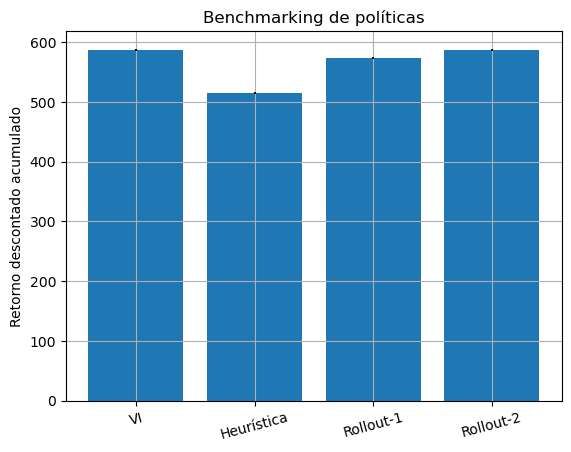

In [29]:
errores_95 = (
    1.96 * errores_estandar
)

plt.bar(
    nombres_politicas,
    medias,
    yerr=errores_95
)

plt.ylabel(
    "Retorno descontado acumulado"
)

plt.title(
    "Benchmarking de políticas"
)

plt.xticks(rotation=15)
plt.grid()
plt.show()

---
## 9. Ejercicio: LogiMax S.A.S. — tres zonas

LogiMax atiende Norte, Sur y Centro con un camión de capacidad 8.

| Zona | Demanda | Precio | Reposición | Almacenamiento | Faltante |
|:---|:---:|---:|---:|---:|---:|
| Norte | $\operatorname{Bin}(5,0.45)$ | 14 | 5 | 1.5 | 20 |
| Sur | $\operatorname{Bin}(4,0.60)$ | 18 | 6 | 2.0 | 25 |
| Centro | $\operatorname{Bin}(3,0.70)$ | 16 | 5 | 1.5 | 22 |

Cada zona puede almacenar de 0 a 3 unidades. Por tanto, hay:

$$
4^3=64
$$

estados.

La codificación es:

$$
\operatorname{indice}(i_N,i_S,i_C)
=
16i_N+4i_S+i_C.
$$

### Checkpoints

1. Construya funciones explícitas para codificar y decodificar un estado.
2. Construya las acciones $(q_N,q_S,q_C)$ mediante tres ciclos y la condición $q_N+q_S+q_C\leq8$.
3. Construya cada zona por separado con `construir_modelo_un_punto`.
4. Antes de combinar todo, calcule manualmente una transición conjunta como producto de tres probabilidades.
5. Construya:
   - una lista de matrices de transición;
   - una matriz de retornos;
   - una matriz de factibilidad.
6. Implemente la heurística $(s,S)^3$:
   - Norte: $(1,3)$;
   - Sur: $(1,3)$;
   - Centro: $(1,2)$.
7. Cuando la capacidad sea insuficiente, asigne unidades priorizando las zonas con mayor razón $b/p$.
8. Evalúe exactamente la heurística.
9. Aplique `calcular_rollout_k_pasos` con uno y dos pasos.
10. Verifique la mejora de rollout-1 respecto de la base. Reporte por separado lo que ocurra entre rollout-2 y rollout-1.
11. Use escenarios comunes, retorno descontado e intervalos emparejados para comparar las políticas.

### Código permitido

Utilice únicamente:

- ciclos ordinarios;
- condicionales;
- listas y matrices sencillas;
- funciones con parámetros directos.

No utilice:

- `zip`;
- `enumerate`;
- comprensiones;
- funciones `lambda`;
- máscaras booleanas;
- funciones pasadas como argumentos.

### Referencias manuales mínimas

Antes de aceptar código generado por IA, compruebe:

- una recompensa de una zona;
- una fila de transición marginal;
- una probabilidad conjunta;
- la suma de una fila de la matriz conjunta;
- una acción de la heurística en un estado sin conflicto;
- una acción de la heurística en un estado con conflicto.

El reto principal es el tamaño del modelo. La lógica de cada paso debe ser la misma utilizada en ColdLink.

---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>